In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import opt_utils
from sweep_max_gap import VehicleConfig, _boundary_conditions, _add_speed_acc_vsp
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({'font.size': 22})

plt.rcParams['font.serif'] = [
    'Palatino', 'Palatino Linotype', 'TeX Gyre Pagella', 'P052',
    'URW Palladio L', 'DejaVu Serif',
]

plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'TeX Gyre Pagella'
plt.rcParams['mathtext.it'] = 'TeX Gyre Pagella:italic'
plt.rcParams['mathtext.bf'] = 'TeX Gyre Pagella:bold'

In [2]:
# One virtual trajectory: 2024-06-18, westbound lane 1, vehicle_index 1120
# (released at t = 4480 s at the upstream boundary).
data = pd.read_csv('data/vt_example.csv').sort_values('time').reset_index(drop=True)
data.head()

,vehicle_index,space,time,speed,speed_diff
0,1120.0,0.040000,4480.0,49.473115,NaN
1,1120.0,0.053536,4481.0,48.217945,1.255170
2,1120.0,0.066834,4482.0,47.677227,0.540718
3,1120.0,0.080155,4483.0,48.383787,0.706560
4,1120.0,0.093608,4484.0,48.251170,0.132617


In [3]:
vehicle = VehicleConfig(sourceTypeID=21, regClassID=20, model_year=2020)

empirical = pd.DataFrame({'time': data['time'].to_numpy(),
                          'space': data['space'].to_numpy()})
empirical = _add_speed_acc_vsp(empirical, vehicle)   # speed (mph), acceleration (miles/s^2), vsp

time_data = empirical['time'].to_numpy()
space_data = empirical['space'].to_numpy()
speed_data = empirical['speed'].to_numpy() / 3600.0  # miles/s, the optimizer's units

In [4]:
v_start, v_end, a_start, a_end = _boundary_conditions(time_data, space_data)

print(f'v_start = {v_start*3600:7.3f} mph   v_end = {v_end*3600:7.3f} mph')
print(f'a_start = {a_start*1609.344:7.3f} m/s^2  a_end = {a_end*1609.344:7.3f} m/s^2')

v_start =  48.728 mph   v_end =  42.733 mph
a_start =  -0.382 m/s^2  a_end =   0.800 m/s^2


In [5]:
MAX_GAPS = [0.1, 0.2]  # miles

MILES_S2_TO_MS2 = 1609.344
solutions = {}

for gap in MAX_GAPS:
    x_smooth, v_smooth, v_avg, cost_value = opt_utils.solve_constrained_smoothing(
        time_data,
        space_data,
        time_data,
        space_data,
        v_start = v_start,
        v_end = v_end,
        a_start = a_start,
        a_end = a_end,
        max_gap = gap
    )

    # Kinematics of the counterfactual through the sweep's own helper, so the
    # curves plotted here are the ones the emission pipeline scores.
    bench = pd.DataFrame({'time': time_data, 'space': x_smooth})
    bench = _add_speed_acc_vsp(bench, vehicle)
    solutions[gap] = {'x': x_smooth, 'df': bench, 'cost': cost_value,
                      'deficit': space_data - x_smooth}

    a_ms2 = bench['acceleration'].to_numpy() * MILES_S2_TO_MS2
    d = solutions[gap]['deficit']
    print(f'max_gap = {gap:.2f} mi | cost = {cost_value:.6g} | '
          f'deficit in [{d.min():.4f}, {d.max():.4f}] mi | '
          f'accel in [{a_ms2.min():.2f}, {a_ms2.max():.2f}] m/s^2')

# Keep the single-gap names alive for the trajectory figure below.
MAX_GAP = MAX_GAPS[0]
x_smooth = solutions[MAX_GAP]['x']

max_gap = 0.10 mi | cost = 0.0243472 | deficit in [-0.0000, 0.1000] mi | accel in [-2.43, 1.56] m/s^2
max_gap = 0.20 mi | cost = 0.0219301 | deficit in [-0.0000, 0.2000] mi | accel in [-3.28, 1.44] m/s^2


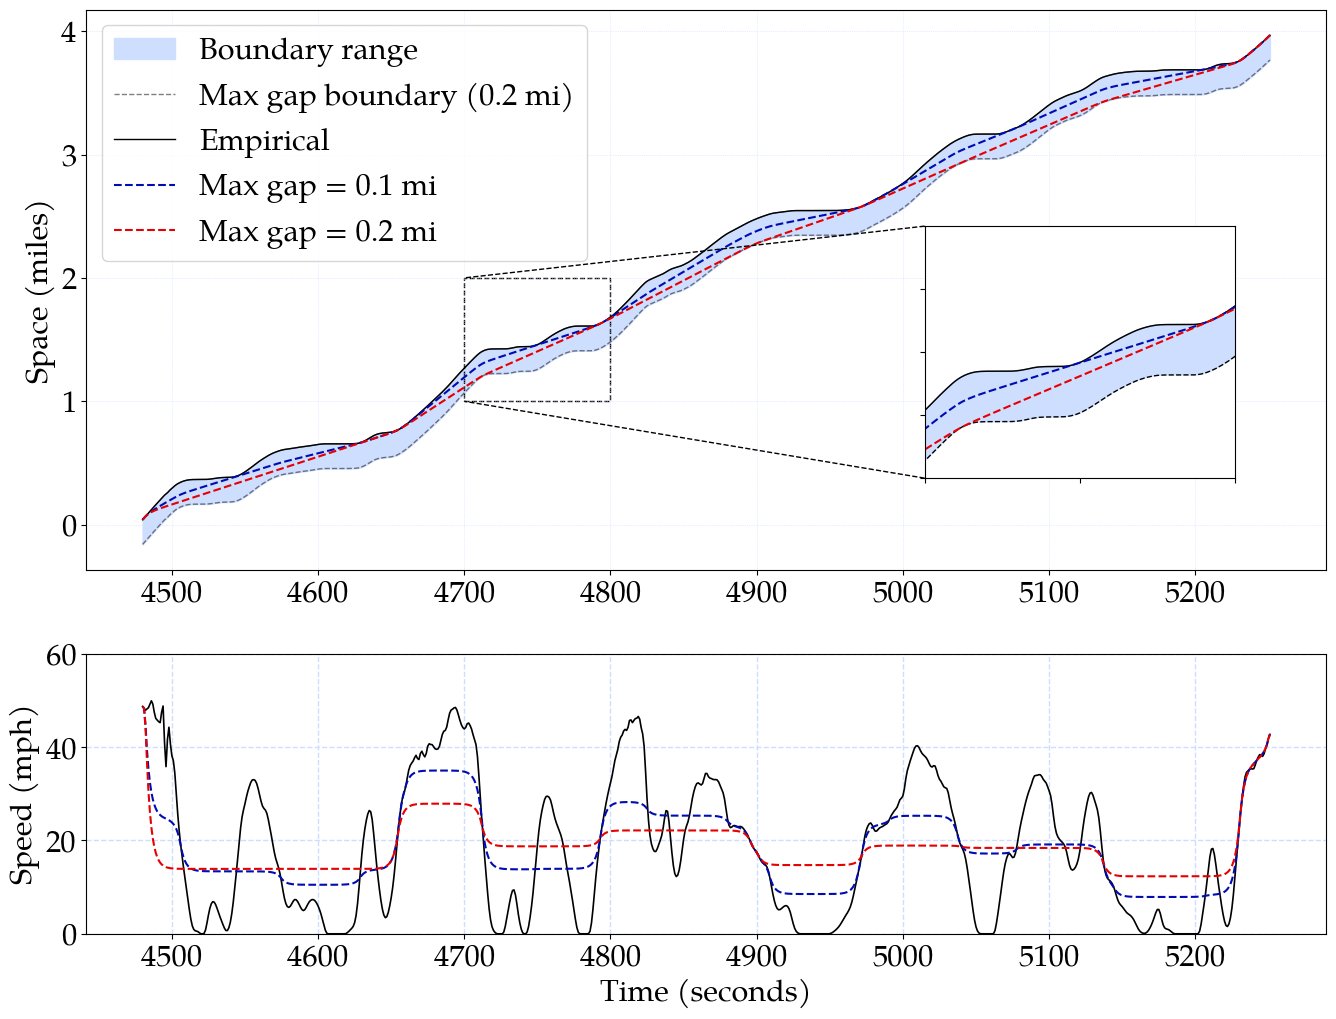

In [6]:
# Appendix view (R2Q5 keeps one zoomed trajectory figure): the same two
# counterfactuals on the time-space diagram, with the wider band drawn.
import viz_palette as vp

COLORS = vp.CHROME["light"]
STYLE = {
    0.1: {'color': vp.PAPER_BLUE, 'lw': 1.5, 'ls': '--', 'label': f'Max gap = {MAX_GAPS[0]} mi'},
    0.2: {'color': vp.PAPER_RED, 'lw': 1.5, 'ls': '--', 'label': f'Max gap = {MAX_GAPS[1]} mi'},
}
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# 1. Setup the figure with two subplots (2 rows, 1 column)
# height_ratios makes the trajectory plot larger to accommodate the inset
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [2, 1]})

upper_bound = space_data
lower_bound = space_data - max(MAX_GAPS)

# --- TOP PLOT: Trajectory ---
ax.fill_between(time_data, lower_bound, upper_bound, 
                 color=COLORS['grid'], label='Boundary range')

ax.plot(time_data, upper_bound, color=COLORS['ink'], lw=1, ls='-', alpha=0.5)
ax.plot(time_data, lower_bound, color=COLORS['ink'], lw=1, ls='--', alpha=0.5, label=f'Max gap boundary ({max(MAX_GAPS)} mi)')

ax.plot(time_data, space_data, color=COLORS['ink'], lw=1, alpha=1, label='Empirical')
for gap in MAX_GAPS:
    ax.plot(time_data, solutions[gap]['x'], **STYLE[gap])

# Create the Zoom Inset
axins = inset_axes(ax, width="25%", height="45%", loc='lower right', borderpad=3)

# Plot the same data into the inset
axins.fill_between(time_data, lower_bound, upper_bound, color=COLORS['grid'])
axins.plot(time_data, upper_bound, color=COLORS['ink'], lw=1, ls='-')
axins.plot(time_data, lower_bound, color=COLORS['ink'], lw=1, ls='--')
axins.plot(time_data, space_data, color=COLORS['ink'], lw=1, alpha=0.3)
for gap in MAX_GAPS:
    axins.plot(time_data, solutions[gap]['x'], **{k: v for k, v in STYLE[gap].items() if k != 'label'})

# Define the Zoom Window
x1, x2 = 4700, 4800   # the benchmark's largest excursion is at t = 4712 s
y1, y2 = 1.0, 2.0    
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.set_xticklabels([])
axins.set_yticklabels([])

# Connector lines
mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec=COLORS["ink"], lw=1, ls='--')

# Note and Formatting for Top Plot
# ax.text(0.45, 0.95, f'Max Gap = {MAX_GAP} miles for demostration purposes', transform=ax.transAxes,
#         fontsize=18, verticalalignment='top')
ax.set_ylabel('Space (miles)')
ax.grid(lw=0.5, ls=':', color=COLORS['grid'])
ax.legend(loc='upper left', frameon=True)

# --- BOTTOM PLOT: Speed ---
ax2.plot(time_data, empirical['speed'], color=COLORS['ink'], lw=1.2, label='Empirical')
for gap in MAX_GAPS:
    ax2.plot(time_data, solutions[gap]['df']['speed'], **{k: v for k, v in STYLE[gap].items() if k != 'label'})

ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Speed (mph)')
ax2.set_ylim(0, 60)
ax2.grid(lw=1, ls='--', color=COLORS['grid'])

if not os.path.exists('figures'):
    os.makedirs('figures')
plt.savefig('figures/demo-space-speed-R1.pdf', bbox_inches='tight', dpi=300)
plt.show()